# Quartis e percentis

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import math

dados = np.array([150, 151, 152, 152, 153, 154, 155, 155, 155, 155, 156, 156, 156,
       157, 158, 158, 160, 160, 160, 160, 160, 161, 161, 161, 161, 162,
       163, 163, 164, 164, 164, 165, 166, 167, 168, 168, 169, 170, 172,
       173])

dados_impar = [150, 151, 152, 152, 153, 154, 155, 155, 155]

## Quartis - Dados não agrupados

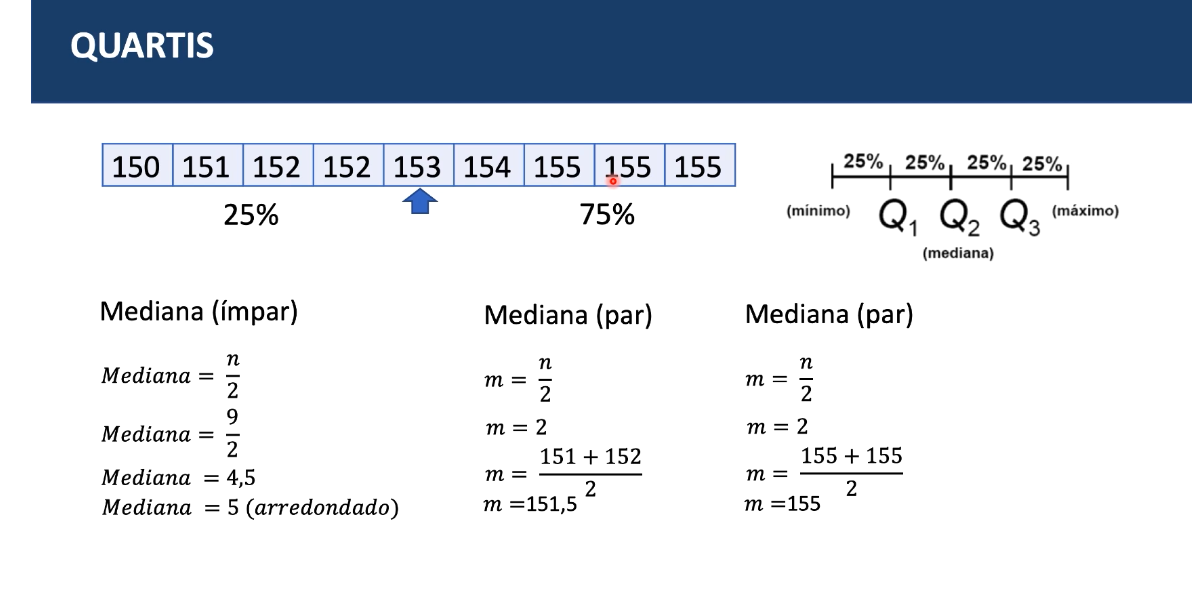

### Cálculo manual

In [2]:
# 50%
np.median(dados_impar)

np.float64(153.0)

In [3]:
posicao_mediana = math.floor(len(dados_impar) / 2)
posicao_mediana

4

In [4]:
# 25%
esquerda = dados_impar[:posicao_mediana]
np.median(esquerda)

np.float64(151.5)

In [5]:
# 75%
direita = dados_impar[posicao_mediana+1:]
np.median(direita)

np.float64(155.0)

## Bibliotecas

### Numpy

In [6]:
np.quantile(dados_impar, 0.25), np.quantile(dados_impar, 0.50), np.quantile(dados_impar, 0.75)

(np.float64(152.0), np.float64(153.0), np.float64(155.0))

### Scipy

In [7]:
stats.scoreatpercentile(dados,25), stats.scoreatpercentile(dados,50), stats.scoreatpercentile(dados,75)

(np.float64(155.75), np.float64(160.0), np.float64(164.0))

### Pandas

In [8]:
dataset = pd.DataFrame(dados)
dataset.quantile([0.25, 0.5, 0.75])

,0
0.25,155.75
0.50,160.00
0.75,164.00


In [9]:
dataset.describe()

,0
count,40.000000
mean,160.375000
std,5.903877
min,150.000000
25%,155.750000
50%,160.000000
75%,164.000000
max,173.000000


## Quartis - Dados agrupados

In [11]:
dados = {'inferior' : [150, 154, 158, 162, 166, 170],
         'superior' : [154, 158, 162, 166, 170, 174],
         'fi' : [5, 9, 11, 7, 5, 3]}

dataset = pd.DataFrame(dados)
dataset['xi'] = (dataset['superior'] + dataset['inferior']) / 2 
dataset['fi.xi'] = dataset['fi'] * dataset['xi']
dataset['Fi'] = 0
frequencia_acumulada = []
somatorio = 0
for _,linha in dataset.iterrows():
    #print(linha['inferior'])
    somatorio += linha['fi']
    frequencia_acumulada.append(somatorio)
dataset['Fi'] = frequencia_acumulada
dataset

,inferior,superior,fi,xi,fi.xi,Fi
0,150,154,5,152.0,760.0,5.0
1,154,158,9,156.0,1404.0,14.0
2,158,162,11,160.0,1760.0,25.0
3,162,166,7,164.0,1148.0,32.0
4,166,170,5,168.0,840.0,37.0
5,170,174,3,172.0,516.0,40.0


In [13]:
def get_quartil(dataframe, q1=True):
    if q1 == True:
        fi_4 = dataset['fi'].sum() /4
    else:
        fi_4 = (3 * dataset['fi'].sum()) / 4
    
    limite_inferior, frequencia_classe, id_frequencia_anterior = 0,0,0
    for linha in dataset.iterrows():
        limite_inferior = linha[1]['inferior']
        frequencia_classe = linha[1]['fi']
        id_frequencia_anterior = linha[0]
        if linha[1]['Fi'] >= fi_4:
            id_frequencia_anterior -=1
            break
    Fi_anterior = dataset.iloc[[id_frequencia_anterior]]['Fi'].values[0]
    q = limite_inferior + ((fi_4 - limite_inferior) * 4) / frequencia_classe

    return q

In [14]:
get_quartil(dados), get_quartil(dados, q1=True)

(np.float64(90.0), np.float64(90.0))

In [15]:
get_quartil(dados), get_quartil(dados, q1=False)

(np.float64(90.0), np.float64(86.57142857142857))

## Percentis

In [17]:
dados = np.array([150, 151, 152, 152, 153, 154, 155, 155, 155, 155, 156, 156, 156,
       157, 158, 158, 160, 160, 160, 160, 160, 161, 161, 161, 161, 162,
       163, 163, 164, 164, 164, 165, 166, 167, 168, 168, 169, 170, 172,
       173])

In [18]:
np.median(dados)

np.float64(160.0)

In [20]:
np.quantile(dados, 0.5)

np.float64(160.0)

In [21]:
np.percentile(dados, 50)

np.float64(160.0)

In [22]:
np.percentile(dados, 5), np.percentile(dados, 10), np.percentile(dados, 90)

(np.float64(151.95), np.float64(152.9), np.float64(168.1))

In [23]:
stats.scoreatpercentile(dados, 5)

np.float64(151.95000000000002)

In [24]:
dataset = pd.DataFrame(dados)
dataset.head()

,0
0,150
1,151
2,152
3,152
4,153


In [25]:
dataset.quantile([0.05, 0.10, 0.90])

,0
0.05,151.95
0.10,152.90
0.90,168.10
